In [1]:
import numpy as np
from os import listdir
import matplotlib.pyplot as plt

In [2]:
from AutoencoderAPI.autoencoderKernelDensity import autoencoder_kerneDensity
from AutoencoderAPI.utils.correlation import second_order
from ExistingAlgorithms.Plot import plot_traces

## NIST dataset

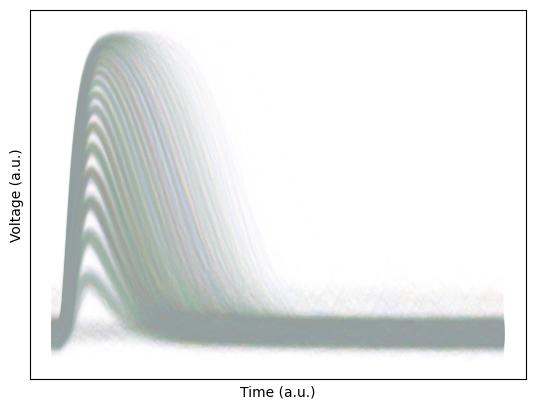

(143360, 250)

In [3]:
signal_size = 250
coherent_29 = 'Datasets/NIST (250) 29dB/'
coherent_28_5 = 'Datasets/NIST (250) 28.5dB/'
coherent_28 = 'Datasets/NIST (250) 28dB/'
path_test = 'Datasets/NIST (250) test/'
path_train = 'Datasets/NIST (250) train/'

X_coherent_29 = np.concatenate([np.fromfile(f"{coherent_29}{fileName}",dtype=np.float16).reshape(-1,signal_size) for fileName in listdir(coherent_29)])
X_coherent_29 = X_coherent_29.astype("double")

X_coherent_28_5 = np.concatenate([np.fromfile(f"{coherent_28_5}{fileName}",dtype=np.float16).reshape(-1,signal_size) for fileName in listdir(coherent_28_5)])
X_coherent_28_5 = X_coherent_28_5.astype("double")

X_coherent_28 = np.concatenate([np.fromfile(f"{coherent_28}{fileName}",dtype=np.float16).reshape(-1,signal_size) for fileName in listdir(coherent_28)])
X_coherent_28 = X_coherent_28.astype("double")

X_test = np.concatenate([np.fromfile(f"{path_test}{fileName}",dtype=np.float16).reshape(-1,signal_size) for fileName in listdir(path_test)])
X_test = X_test.astype("double")

X_train = np.concatenate([np.fromfile(f"{path_train}{fileName}",dtype=np.float16).reshape(-1,signal_size) for fileName in listdir(path_train)])
X_train = X_train.astype("double")

X = np.concatenate((X_test,X_train))

plot_traces(np.copy(X))
np.shape(X)

### Autoencoder

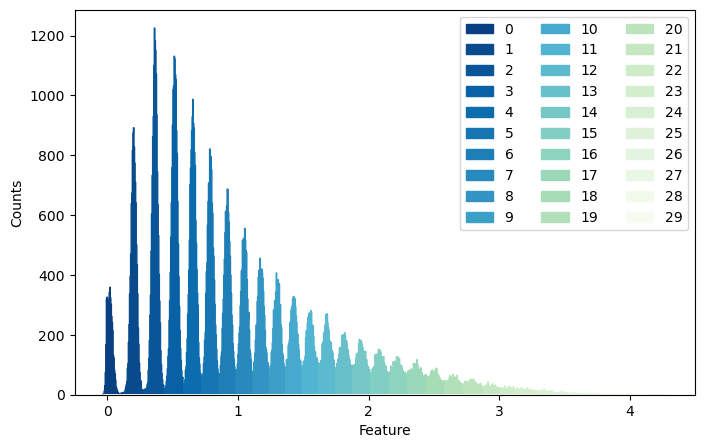

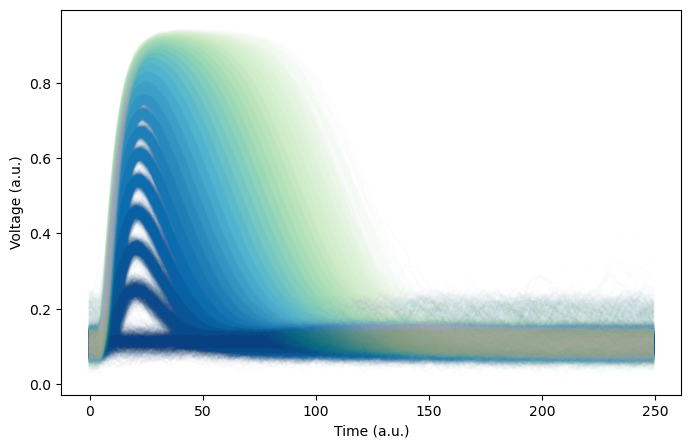

In [4]:
kd = autoencoder_kerneDensity("Autoencoder Log/run-2023-09-05-18-52/fold 0")
kd.fit_cluster(X, plot_density=False, plot_cluster=True, plot_traces=True)

### 29dB Attenuation (Coherent state)

Second order correlation :  1.0049186094247906
Number of traces :  20480


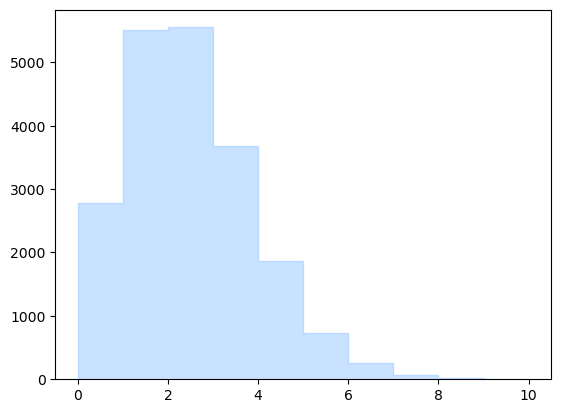

In [5]:
labels_29 = kd.get_label(X_coherent_29)
g2_29 = second_order(labels_29)

print("Second order correlation : ", g2_29)
print("Number of traces : ", len(labels_29))

plt.figure()
plt.hist(labels_29, alpha = 0.5, fill=True, histtype='step')
plt.show()

### 28.5dB Attenuation (Coherent state)

Second order correlation :  1.0102209518569216
Number of traces :  20480


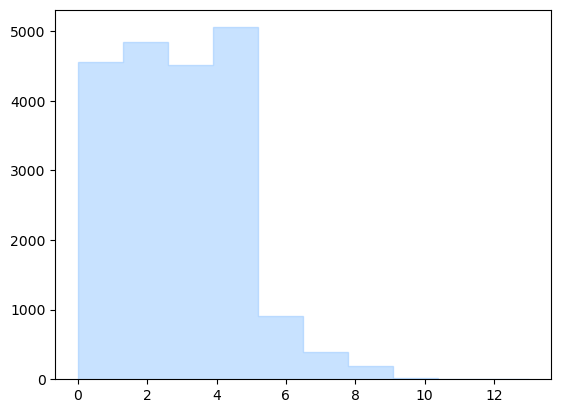

In [6]:
labels_28_5 = kd.get_label(X_coherent_28_5)
g2_28_5 = second_order(labels_28_5)

print("Second order correlation : ", g2_28_5)
print("Number of traces : ", len(labels_28_5))

plt.figure()
plt.hist(labels_28_5, alpha = 0.5, fill=True, histtype='step')
plt.show()

### 28dB Attenuation (Coherent state)

Second order correlation :  0.9964658842626439
Number of traces :  20480


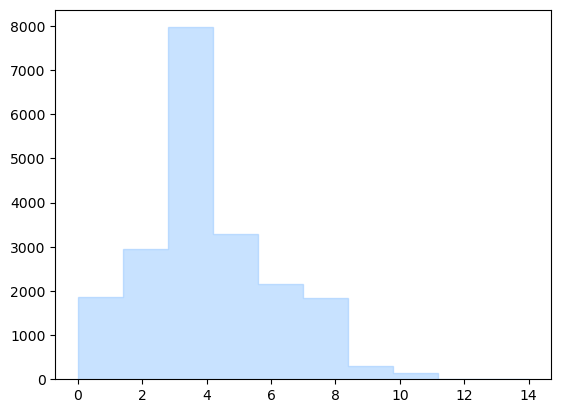

In [7]:
labels_28 = kd.get_label(X_coherent_28)
g2_28 = second_order(labels_28)

print("Second order correlation : ", g2_28)
print("Number of traces : ", len(labels_28))

plt.figure()
plt.hist(labels_28, alpha = 0.5, fill=True, histtype='step')
plt.show()

### 26dB - 29dB Attenuation (Multiple coherent state)

Second order correlation :  1.425650719992703
Number of traces :  143360


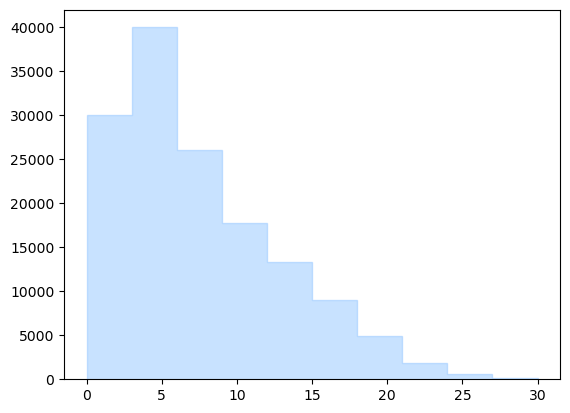

In [8]:
labels_tot = kd.get_label(X)
g2_tot = second_order(labels_tot)

print("Second order correlation : ", g2_tot)
print("Number of traces : ", len(labels_tot))

plt.figure()
plt.hist(labels_tot, alpha = 0.5, fill=True, histtype='step')
plt.show()

## Oxford dataset (Thermal state)

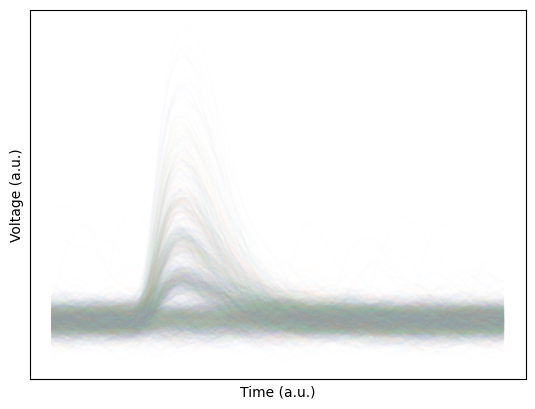

In [9]:
signal_size = 496
Oxford = 'Datasets/Oxford/'

X_Oxford = np.concatenate([np.fromfile(f"{Oxford}{fileName}",dtype=np.float16).reshape(-1,signal_size) for fileName in listdir(Oxford)])
X_Oxford = X_Oxford.astype("double")

plot_traces(np.copy(X_Oxford))

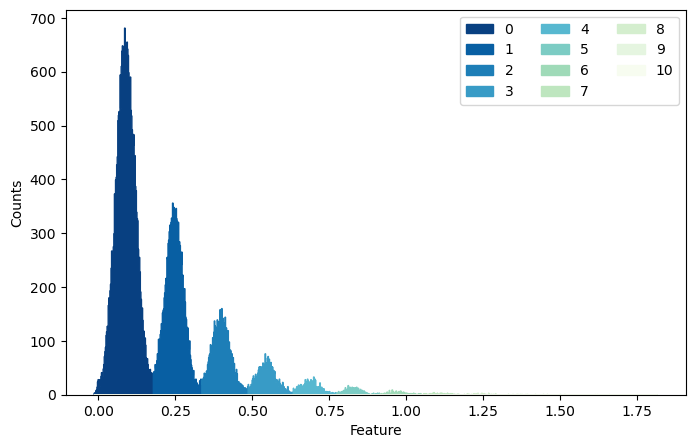

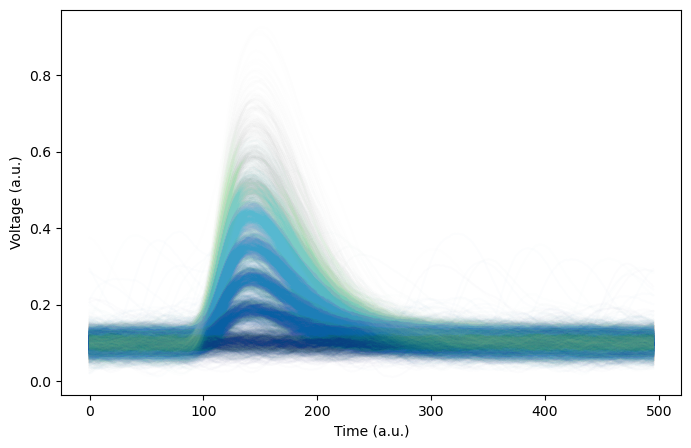

In [10]:
kd = autoencoder_kerneDensity("Autoencoder Log/run-2023-09-05-22-12/fold 0")
kd.fit_cluster(X_Oxford, plot_density=False, plot_cluster=True, plot_traces=True)

Second order correlation :  1.8331675929201907
Number of traces :  52224


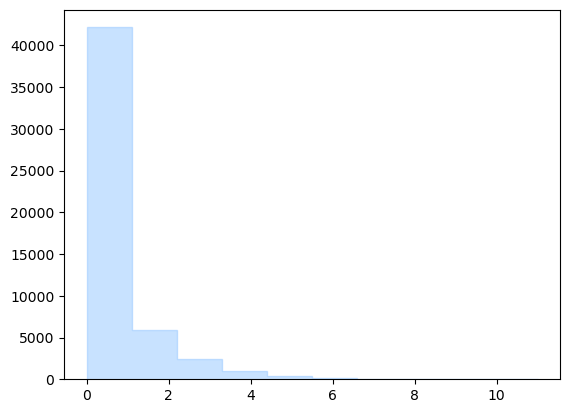

In [11]:
labels_ox = kd.get_label(X_Oxford)
g2_ox = second_order(labels_ox)

print("Second order correlation : ", g2_ox)
print("Number of traces : ", len(labels_ox))

plt.figure()
plt.hist(labels_ox, alpha = 0.5, fill=True, histtype='step')
plt.show()